In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
train_df = pd.read_csv("/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv")
sample_sub = pd.read_csv("/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/sample_submission.csv")

In [4]:
# datatypes info
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   phrase     7000 non-null   object 
 2   feature_1  6088 non-null   float64
 3   feature_2  5896 non-null   float64
 4   feature_3  5938 non-null   float64
 5   sentiment  7000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 328.3+ KB


In [5]:
#statistical analysis
train_df.describe()

,id,feature_1,feature_2,feature_3,sentiment
count,7000.000000,6088.000000,5896.000000,5938.000000,7000.000000
mean,3499.500000,19.025624,1.996608,3.334119,1.041143
std,2020.870275,9.303562,1.634858,2.321154,0.898010
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1749.750000,12.000000,1.000000,2.000000,0.000000
50%,3499.500000,18.000000,1.000000,3.000000,1.000000
75%,5249.250000,25.000000,3.000000,4.000000,2.000000
max,6999.000000,52.000000,19.000000,19.000000,2.000000


In [6]:
#identyfing missing values
train_df.isnull().sum()

id              0
phrase          0
feature_1     912
feature_2    1104
feature_3    1062
sentiment       0
dtype: int64

In [7]:
#checking duplicate values
train_df.duplicated().sum()
# here 0 so no need to handle

np.int64(0)

In [8]:
train_df

,id,phrase,feature_1,feature_2,feature_3,sentiment
0,0,It may as well be called `` Jar-Jar Binks : Th...,14.0,5.0,7.0,0
1,1,You have to see it .,6.0,1.0,NaN,2
2,2,... either you 're willing to go with this cla...,16.0,0.0,6.0,1
3,3,Watching Harris ham it up while physically and...,37.0,NaN,3.0,1
4,4,Pete 's screenplay manages to find that real n...,20.0,1.0,4.0,2
...,...,...,...,...,...,...
6995,6995,"A fantastic premise anchors this movie , but w...",41.0,3.0,NaN,1
6996,6996,"A boring , pretentious muddle that uses a sens...",37.0,2.0,11.0,0
6997,6997,"Boy , has this franchise ever run out of gas .",11.0,1.0,2.0,0
6998,6998,It 's hard to understand why anyone in his rig...,21.0,1.0,2.0,0


In [9]:
train_df.corr(numeric_only=True)

,id,feature_1,feature_2,feature_3,sentiment
id,1.000000,0.025711,-0.005174,0.011938,-0.008502
feature_1,0.025711,1.000000,0.388982,0.561413,0.023135
feature_2,-0.005174,0.388982,1.000000,0.272237,0.038526
feature_3,0.011938,0.561413,0.272237,1.000000,0.004803
sentiment,-0.008502,0.023135,0.038526,0.004803,1.000000


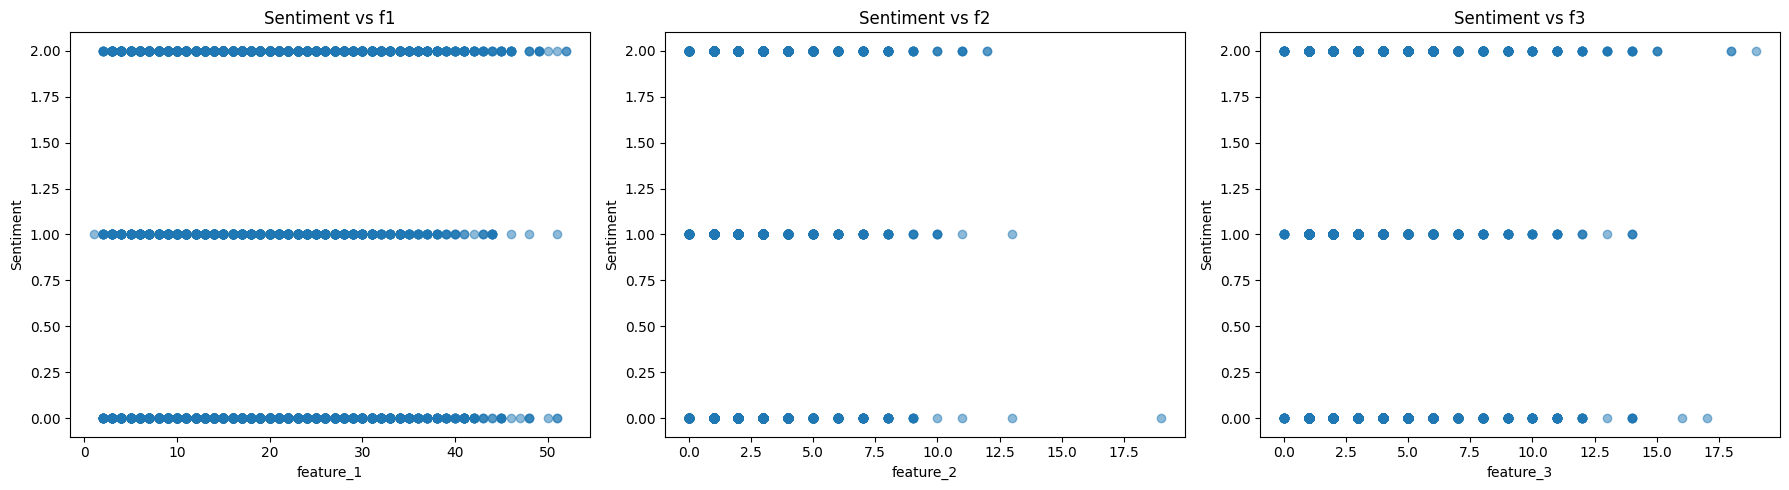

In [10]:
# 3 visualiations


plt.figure(figsize=(18, 5))
y = train_df['sentiment']
# Plot 1: f1 vs sentiment
plt.subplot(1, 3, 1)
plt.scatter(train_df['feature_1'], y, alpha=0.5)
plt.xlabel('feature_1')
plt.ylabel('Sentiment')
plt.title('Sentiment vs f1')

# Plot 2: f2 vs sentiment
plt.subplot(1, 3, 2)
plt.scatter(train_df['feature_2'], y, alpha=0.5)
plt.xlabel('feature_2')
plt.ylabel('Sentiment')
plt.title('Sentiment vs f2')

# Plot 3: f3 vs sentiment
plt.subplot(1, 3, 3)
plt.scatter(train_df['feature_3'], y, alpha=0.5)
plt.xlabel('feature_3')
plt.ylabel('Sentiment')
plt.title('Sentiment vs f3')

plt.tight_layout()
plt.show()

In [11]:
train_df['phrase'][6997]

'Boy , has this franchise ever run out of gas .'

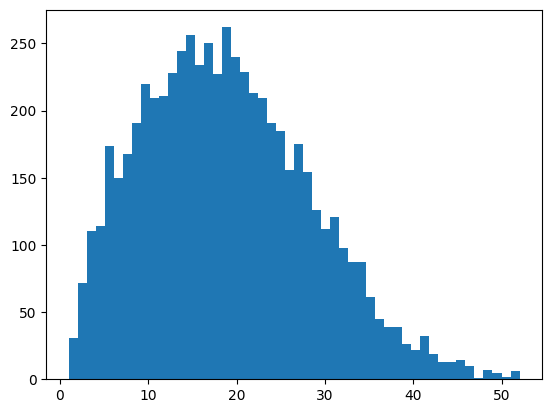

In [12]:
plt.hist(train_df["feature_1"],50)
plt.show()

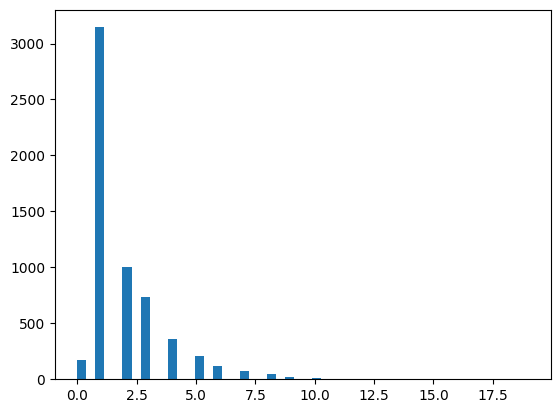

In [13]:
plt.hist(train_df["feature_2"],50)
plt.show()

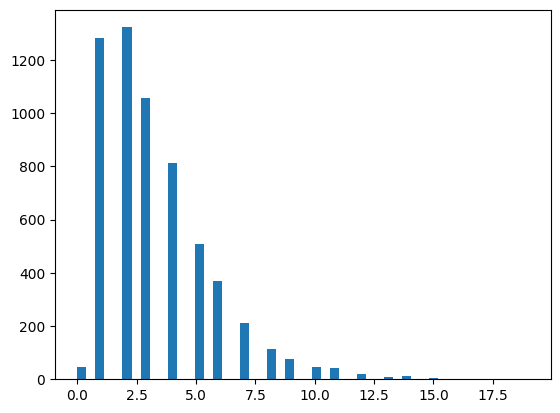

In [14]:
plt.hist(train_df["feature_3"],50)
plt.show()

In [15]:
# module imports

import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import RidgeClassifier, PassiveAggressiveClassifier, SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

In [16]:
# imputation Functions (derived from phrase metadata)
# removving na values
def get_f1(text): return len(str(text).split())
def get_f2(text): return sum(1 for t in str(text).split() if t and t[0].isupper())
def get_f3(text): return sum(1 for char in str(text) if char in string.punctuation)

for df in [train_df, test_df]:
    df['feature_1'] = df['feature_1'].fillna(df['phrase'].apply(get_f1))
    df['feature_2'] = df['feature_2'].fillna(df['phrase'].apply(get_f2))
    df['feature_3'] = df['feature_3'].fillna(df['phrase'].apply(get_f3))

# 3. Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('word_tfidf', TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 3), max_features=15000), 'phrase'),
        ('char_tfidf', TfidfVectorizer(sublinear_tf=True, analyzer='char', ngram_range=(2, 5), max_features=10000), 'phrase'),
        ('num', MinMaxScaler(), ['feature_1', 'feature_2', 'feature_3']) 
    ])

In [17]:
# 4. Ensemble Definition
clf1 = LogisticRegression(C=12, solver='liblinear', random_state=42)
clf2 = MultinomialNB(alpha=0.1)
clf3 = LinearSVC(C=0.5, random_state=42, max_iter=2000)
lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

xgbm = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
ridge = RidgeClassifier(alpha=1.0, random_state=42)
pa = PassiveAggressiveClassifier(C=1.0, random_state=42, max_iter=1000)
sgd = SGDClassifier(loss='hinge', max_iter=1000, random_state=42)

pipe_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgbm)
])

pipe_xgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgbm)
])


pipe_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ridge)
])

pipe_pa = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', pa)
])

pipe_sgd = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', sgd)
])

linear_models = {
    "Ridge": pipe_ridge,
    "PassiveAggressive": pipe_pa,
    "SGD": pipe_sgd
}

X = train_df[['phrase', 'feature_1', 'feature_2', 'feature_3']]
y = train_df['sentiment']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

score_lgbm = cross_val_score(pipe_lgbm, X_train, y_train, cv=5, scoring='accuracy').mean()
score_xgbm = cross_val_score(pipe_xgbm, X_train, y_train, cv=5, scoring='accuracy').mean()

print("LGBM Accuracy:", score_lgbm)
print("XGBM Accuracy:", score_xgbm)



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.421561 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 370353
[LightGBM] [Info] Number of data points in the train set: 4480, number of used features: 10553
[LightGBM] [Info] Start training from score -0.954396
[LightGBM] [Info] Start training from score -1.673976
[LightGBM] [Info] Start training from score -0.849905


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.400977 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 371761
[LightGBM] [Info] Number of data points in the train set: 4480, number of used features: 10560
[LightGBM] [Info] Start training from score -0.954396
[LightGBM] [Info] Start training from score -1.673976
[LightGBM] [Info] Start training from score -0.849905


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.410771 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 370103
[LightGBM] [Info] Number of data points in the train set: 4480, number of used features: 10564
[LightGBM] [Info] Start training from score -0.954396
[LightGBM] [Info] Start training from score -1.673976
[LightGBM] [Info] Start training from score -0.849905


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.400598 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 372037
[LightGBM] [Info] Number of data points in the train set: 4480, number of used features: 10560
[LightGBM] [Info] Start training from score -0.954396
[LightGBM] [Info] Start training from score -1.673976
[LightGBM] [Info] Start training from score -0.849905


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.398746 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 368548
[LightGBM] [Info] Number of data points in the train set: 4480, number of used features: 10553
[LightGBM] [Info] Start training from score -0.954976
[LightGBM] [Info] Start training from score -1.673976
[LightGBM] [Info] Start training from score -0.849383


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:44:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:49:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:54:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:58:43] WARNING: /__w/xg

LGBM Accuracy: 0.5991071428571428
XGBM Accuracy: 0.5880357142857143


In [18]:
# 4. Ensemble Definition
def make_pipeline(model):
    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

ensemble = VotingClassifier(
    estimators=[
        ('lr', make_pipeline(clf1)),
        ('nb', make_pipeline(clf2)),
        ('svc', make_pipeline(clf3)),
        ('lgbm', make_pipeline(lgbm)),
        ('xgbm', make_pipeline(xgbm))
    ],
    voting='hard'
)
model_pipeline = model_pipeline = ensemble

In [19]:


# 5. Model Comparison and Validation
print("Comparing models on validation set")

# Individual Pipeline for Ensemble
# and we can use the pipes defined earlier for LGBM/XGBM

models = {
    "LGBM": pipe_lgbm,
    "XGBM": pipe_xgbm,
    "Ensemble": model_pipeline,
    "Ridge": pipe_ridge,
    "PassiveAggressive": pipe_pa,
    "SGD": pipe_sgd
}

best_val_acc = 0
best_model_name = ""

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    print(f"{name} Validation Accuracy: {acc:.4f}")
    
    if acc > best_val_acc:
        best_val_acc = acc
        best_model_name = name

print(f"Conclusion: {best_model_name} performed best.")

# 6. Final Fit using the "Winner"
print(f"Refitting {best_model_name} on 100% of data for submission...")
final_model = models[best_model_name]
final_model.fit(X, y)

# 7. Generate Final Submission
test_features = test_df[['phrase', 'feature_1', 'feature_2', 'feature_3']]
test_preds = final_model.predict(test_features)


submission = pd.DataFrame({'id': test_df['id'], 'sentiment': test_preds})
submission.to_csv("submission.csv", index=False)
print("done :)")

Comparing models on validation set
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.528830 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 443265
[LightGBM] [Info] Number of data points in the train set: 5600, number of used features: 10723
[LightGBM] [Info] Start training from score -0.954512
[LightGBM] [Info] Start training from score -1.673976
[LightGBM] [Info] Start training from score -0.849801


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBM Validation Accuracy: 0.6164


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:10:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBM Validation Accuracy: 0.5621
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.524407 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 443265
[LightGBM] [Info] Number of data points in the train set: 5600, number of used features: 10723
[LightGBM] [Info] Start training from score -0.954512
[LightGBM] [Info] Start training from score -1.673976
[LightGBM] [Info] Start training from score -0.849801


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:17:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Ensemble Validation Accuracy: 0.6357
Ridge Validation Accuracy: 0.6207
PassiveAggressive Validation Accuracy: 0.6107
SGD Validation Accuracy: 0.6200
Conclusion: Ensemble performed best.
Refitting Ensemble on 100% of data for submission...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.674754 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 527713
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 10914
[LightGBM] [Info] Start training from score -0.958602
[LightGBM] [Info] Start training from score -1.650260
[LightGBM] [Info] Start training from score -0.856675


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:25:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


done :)
